In [ ]:
# SUBJECT_IDS = list(range(1, 11)) # first ten
SUBJECT_IDS = list(range(1, 110)) # full
RUNS_FOR_TRAINING = [3, 7]
RUNS_FOR_TESTING = [11]


In [14]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import mne
from mne.decoding import CSP

In [19]:
# 1. Silence MNE logs and suppress deprecation warnings
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore", category=FutureWarning)

def load_and_epoch(subject_id: int, runs: list, tmin=0.5, tmax=3.5, l_freq=8.0, h_freq=30.0, target_sfreq=160.0):
    file_paths = mne.datasets.eegbci.load_data(subjects=subject_id, runs=runs, update_path=False, verbose=False)
    
    raws = []
    for f in file_paths:
        r = mne.io.read_raw_edf(f, preload=True, verbose=False)
        mne.datasets.eegbci.standardize(r)
        raws.append(r)
    
    montage = mne.channels.make_standard_montage('colin27_1005')
    raw = mne.concatenate_raws(raws, verbose=False)
    raw.set_montage(montage, match_case=False)
    
    # 1. Enforce uniform sampling rate across all subjects
    if raw.info['sfreq'] != target_sfreq:
        raw.resample(target_sfreq, verbose=False)
    
    # 2. Bandpass filter
    raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge', verbose=False)
    
    # 3. Parse annotations
    events, event_dict = mne.events_from_annotations(raw, event_id={'T1': 1, 'T2': 2}, verbose=False)
    
    epochs = mne.Epochs(
        raw, events, event_id=event_dict, 
        tmin=tmin, tmax=tmax, baseline=None, 
        preload=True, verbose=False
    )
    
    # Ensure exact sample length (slicing guarantees 481 points in edge rounding cases)
    X = epochs.get_data(copy=False)[:, :, :481]
    y = epochs.events[:, -1] - 1
    
    return epochs, X, y

In [ ]:
# 2. Cache the data to avoid reading EDF files many separate times
print(f"Caching data for Subjects {SUBJECT_IDS[0]}-{SUBJECT_IDS[-1]}...")
train_data_cache = {}
test_data_cache = {}

for sub in SUBJECT_IDS:
    _, X_tr, y_tr = load_and_epoch(sub, RUNS_FOR_TRAINING)
    _, X_te, y_te = load_and_epoch(sub, RUNS_FOR_TESTING)
    train_data_cache[sub] = (X_tr, y_tr)
    test_data_cache[sub] = (X_te, y_te)

Caching data for Subjects 1-10...


C:\Users\jason\AppData\Local\Temp\ipykernel_24604\2541838296.py:10: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  r = mne.io.read_raw_edf(f, preload=True, verbose=False)
C:\Users\jason\AppData\Local\Temp\ipykernel_24604\2541838296.py:10: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  r = mne.io.read_raw_edf(f, preload=True, verbose=False)
C:\Users\jason\AppData\Local\Temp\ipykernel_24604\2541838296.py:10: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  r = mne.io.read_raw_edf(f, preload=True, verbose=False)


In [22]:
# 3. Execute Leave-One-Subject-Out (LOSO) Evaluation
loso_records = []

print("\n=== Starting Inter-Subject (LOSO) Benchmark ===")
for test_sub in SUBJECT_IDS:
    train_subs = [s for s in SUBJECT_IDS if s != test_sub]
    
    # Pool Runs 3 & 7 from the 9 training subjects
    X_train_pooled = np.concatenate([train_data_cache[s][0] for s in train_subs], axis=0)
    y_train_pooled = np.concatenate([train_data_cache[s][1] for s in train_subs], axis=0)
    
    # Retrieve Run 11 for the held-out test subject
    X_test_heldout, y_test_heldout = test_data_cache[test_sub]
    
    pipe = Pipeline([
        ("CSP", CSP(n_components=4, reg='ledoit_wolf', log=True, norm_trace=False)),
        ("LDA", LinearDiscriminantAnalysis())
    ])
    
    pipe.fit(X_train_pooled, y_train_pooled)
    acc = pipe.score(X_test_heldout, y_test_heldout)
    
    loso_records.append({
        "Subject": f"S{test_sub:02d}",
        "Accuracy": acc
    })
    
    print(f"Held-out Subject {test_sub:02d} | Accuracy: {acc:6.2%} (Test trials: {len(y_test_heldout)})")


=== Starting Inter-Subject (LOSO) Benchmark ===
Held-out Subject 01 | Accuracy: 86.67% (Test trials: 15)
Held-out Subject 02 | Accuracy: 46.67% (Test trials: 15)
Held-out Subject 03 | Accuracy: 33.33% (Test trials: 15)
Held-out Subject 04 | Accuracy: 53.33% (Test trials: 15)
Held-out Subject 05 | Accuracy: 53.33% (Test trials: 15)
Held-out Subject 06 | Accuracy: 53.33% (Test trials: 15)
Held-out Subject 07 | Accuracy: 66.67% (Test trials: 15)
Held-out Subject 08 | Accuracy: 33.33% (Test trials: 15)
Held-out Subject 09 | Accuracy: 53.33% (Test trials: 15)
Held-out Subject 10 | Accuracy: 46.67% (Test trials: 15)
Held-out Subject 11 | Accuracy: 46.67% (Test trials: 15)
Held-out Subject 12 | Accuracy: 93.33% (Test trials: 15)
Held-out Subject 13 | Accuracy: 73.33% (Test trials: 15)
Held-out Subject 14 | Accuracy: 53.33% (Test trials: 15)
Held-out Subject 15 | Accuracy: 53.33% (Test trials: 15)
Held-out Subject 16 | Accuracy: 80.00% (Test trials: 15)
Held-out Subject 17 | Accuracy: 53.33% 


Cohort Size: 109 subjects evaluated
Inter-Subject LOSO Mean Accuracy: 57.98% ± 13.26% (SD)
Standard Error (SEM): ± 1.27%
95% Confidence Interval: [55.47%, 60.50%]
One-Sample t-test (vs 50%): t(108) = 6.286
  p-value (one-tailed, μ > 0.50): 0.0000
  p-value (two-tailed, μ ≠ 0.50): 0.0000
Min / Max: 33.33% / 100.00%


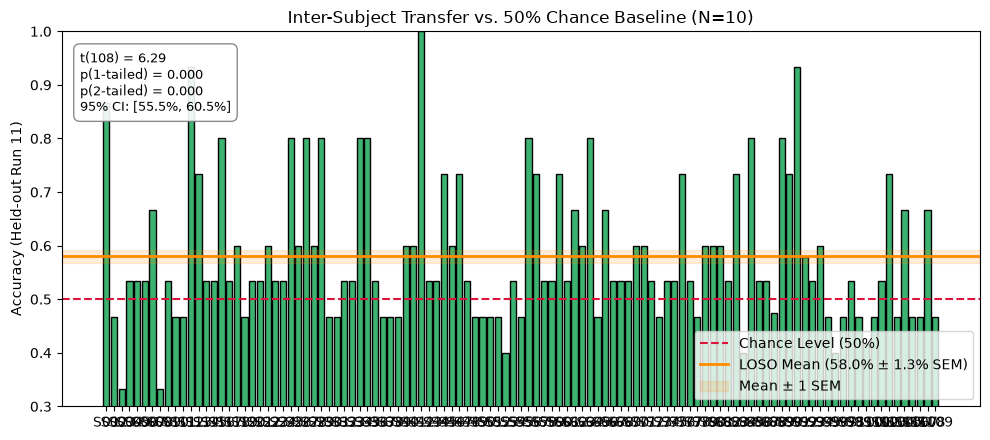

In [23]:
# 4. Summary and Visualization with Statistical Significance
from scipy import stats

df_loso = pd.DataFrame(loso_records)

accuracies = df_loso['Accuracy'].values
n = len(accuracies)
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies, ddof=1)
sem_acc = std_acc / np.sqrt(n)

# Inferential stats against 50% chance
t_stat, p_val_two_sided = stats.ttest_1samp(accuracies, popmean=0.50)
p_val_one_sided = p_val_two_sided / 2 if t_stat > 0 else 1.0 - (p_val_two_sided / 2)
ci_lower, ci_upper = stats.t.interval(0.95, df=n - 1, loc=mean_acc, scale=sem_acc)

print("\n" + "=" * 48)
print(f"Cohort Size: {n} subjects evaluated")
print(f"Inter-Subject LOSO Mean Accuracy: {mean_acc:.2%} ± {std_acc:.2%} (SD)")
print(f"Standard Error (SEM): ± {sem_acc:.2%}")
print(f"95% Confidence Interval: [{ci_lower:.2%}, {ci_upper:.2%}]")
print(f"One-Sample t-test (vs 50%): t({n-1}) = {t_stat:.3f}")
print(f"  p-value (one-tailed, μ > 0.50): {p_val_one_sided:.4f}")
print(f"  p-value (two-tailed, μ ≠ 0.50): {p_val_two_sided:.4f}")
print(f"Min / Max: {df_loso['Accuracy'].min():.2%} / {df_loso['Accuracy'].max():.2%}")
print("=" * 48)

plt.figure(figsize=(10, 4.5))
plt.bar(df_loso["Subject"], df_loso["Accuracy"], color="mediumseagreen", edgecolor="black")
plt.axhline(0.50, color="crimson", linestyle="--", linewidth=1.5, label="Chance Level (50%)")

# Plot mean line and shaded ±1 SEM band
plt.axhline(mean_acc, color="darkorange", linestyle="-", linewidth=2, 
            label=f"LOSO Mean ({mean_acc:.1%} ± {sem_acc:.1%} SEM)")
plt.axhspan(mean_acc - sem_acc, mean_acc + sem_acc, color="darkorange", alpha=0.15, label="Mean ± 1 SEM")

# Statistical significance annotation badge
stat_text = (
    f"t({n-1}) = {t_stat:.2f}\n"
    f"p(1-tailed) = {p_val_one_sided:.3f}\n"
    f"p(2-tailed) = {p_val_two_sided:.3f}\n"
    f"95% CI: [{ci_lower:.1%}, {ci_upper:.1%}]"
)
plt.gca().text(
    0.02, 0.95, stat_text, transform=plt.gca().transAxes,
    fontsize=9, verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.ylim(0.3, 1.0)
plt.ylabel("Accuracy (Held-out Run 11)")
plt.title("Inter-Subject Transfer vs. 50% Chance Baseline (N=10)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()